# 🧮 CS229 Lecture 3: Locally Weighted & Logistic Regression

## Stanford CS229: Machine Learning

In this notebook, we implement **from scratch**:

### Part 1: Locally Weighted Regression (LWR)
- Non-parametric regression
- Gaussian weighting function
- Effect of bandwidth parameter $\tau$

### Part 2: Logistic Regression (Classification)
- Sigmoid function
- Binary Cross-Entropy cost function
- Gradient Descent for classification
- Decision boundary visualization

### Part 3: Newton's Method
- Second-order optimization
- Hessian matrix computation
- Comparison with Gradient Descent

---

### Key Equations

**Locally Weighted Regression:**
$$w^{(i)} = \exp\left(-\frac{(x^{(i)} - x)^2}{2\tau^2}\right)$$

**Logistic Regression Hypothesis:**
$$h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}}$$

**Binary Cross-Entropy Cost:**
$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

**Newton's Method Update:**
$$\theta := \theta - H^{-1} \nabla_\theta J(\theta)$$

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [25]:
from matplotlib import rcParams

rcParams["font.family"] = "DejaVu Sans"

---
# Part 1: Locally Weighted Regression (LWR)
---

## 1.1 The Problem

Standard linear regression fits **one global line** to all data.
But real-world data is often **non-linear**.

**Locally Weighted Regression** fits a **different linear model** for each query point,
giving **more weight** to nearby training examples.

### Weighted Cost Function

For each query point $x$, minimize:

$$\sum_{i=1}^{m} w^{(i)} \left(\theta^T x^{(i)} - y^{(i)}\right)^2$$

where the weights are:

$$w^{(i)} = \exp\left(-\frac{(x^{(i)} - x)^2}{2\tau^2}\right)$$

$\tau$ = **bandwidth parameter** (controls how quickly weights decay with distance)

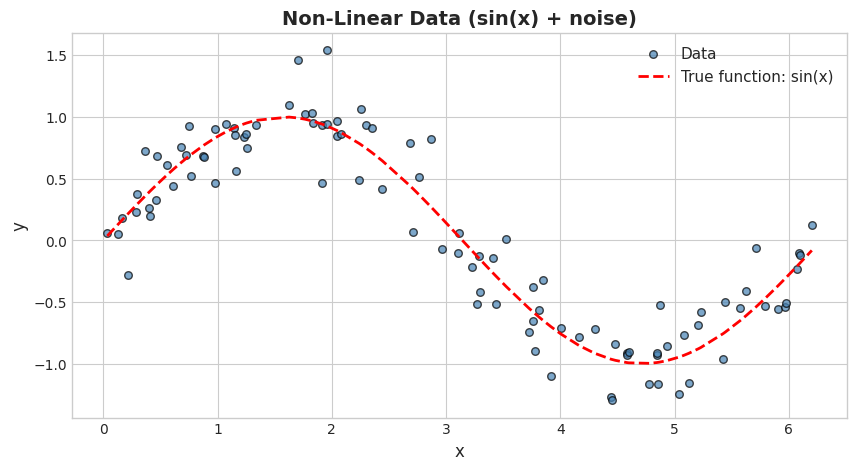

📊 A straight line would be a terrible fit for this data!
   We need something more flexible → Locally Weighted Regression


In [26]:
# Generate non-linear data
m = 100
X_lwr = np.sort(np.random.uniform(0, 2 * np.pi, m))
y_lwr = np.sin(X_lwr) + np.random.normal(0, 0.25, m)

plt.figure(figsize=(10, 5))
plt.scatter(X_lwr, y_lwr, color='steelblue', s=30, alpha=0.7, edgecolors='k', label='Data')
plt.plot(np.sort(X_lwr), np.sin(np.sort(X_lwr)), 'r--', linewidth=2, label='True function: sin(x)')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Non-Linear Data (sin(x) + noise)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.show()

print("📊 A straight line would be a terrible fit for this data!")
print("   We need something more flexible → Locally Weighted Regression")

## 1.2 Implementing LWR from Scratch

**Algorithm:**
1. For each query point $x_q$:
   - Compute weights $w^{(i)}$ for all training examples
   - Solve the weighted least squares problem
   - Return prediction at $x_q$

**Closed-form weighted solution:**

$$\theta = (X^T W X)^{-1} X^T W \vec{y}$$

where $W$ is a diagonal matrix with $W_{ii} = w^{(i)}$

In [27]:
def compute_weights(X_train, x_query, tau):
    """
    Compute Gaussian weights for each training example
    relative to the query point.
    
    w(i) = exp(-(x(i) - x_query)^2 / (2 * tau^2))
    
    Parameters:
        X_train: (m,) training inputs
        x_query: scalar query point
        tau: bandwidth parameter
    
    Returns:
        W: (m, m) diagonal weight matrix
    """
    diff = X_train - x_query
    weights = np.exp(-(diff ** 2) / (2 * tau ** 2))
    W = np.diag(weights)
    return W


def lwr_predict_single(X_train, y_train, x_query, tau):
    """
    Make a single prediction using Locally Weighted Regression.
    
    θ = (X^T W X)^(-1) X^T W y
    prediction = x_query^T @ θ
    
    Parameters:
        X_train: (m,) training inputs
        y_train: (m,) training targets
        x_query: scalar query point
        tau: bandwidth parameter
    
    Returns:
        prediction: scalar predicted value
    """
    m = len(X_train)
    
    # Design matrix with intercept
    X = np.c_[np.ones(m), X_train]
    
    # Compute weight matrix
    W = compute_weights(X_train, x_query, tau)
    
    # Weighted normal equation: θ = (X^T W X)^(-1) X^T W y
    theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y_train)
    
    # Predict at query point
    x_q = np.array([1, x_query])
    prediction = x_q @ theta
    
    return prediction


def lwr_predict(X_train, y_train, X_query, tau):
    """
    Make predictions for multiple query points.
    
    Parameters:
        X_train: (m,) training inputs
        y_train: (m,) training targets
        X_query: (k,) query points
        tau: bandwidth parameter
    
    Returns:
        predictions: (k,) predicted values
    """
    predictions = np.array([
        lwr_predict_single(X_train, y_train, xq, tau)
        for xq in X_query
    ])
    return predictions


print("✅ LWR functions defined!")
print("\nKey functions:")
print("  • compute_weights(X_train, x_query, tau) → Weight matrix W")
print("  • lwr_predict_single(X_train, y_train, x_query, tau) → Single prediction")
print("  • lwr_predict(X_train, y_train, X_query, tau) → Multiple predictions")

✅ LWR functions defined!

Key functions:
  • compute_weights(X_train, x_query, tau) → Weight matrix W
  • lwr_predict_single(X_train, y_train, x_query, tau) → Single prediction
  • lwr_predict(X_train, y_train, X_query, tau) → Multiple predictions


## 1.3 Visualizing the Weights

Let's see how the Gaussian weighting function works.
For a given query point, nearby training examples get **high weight**
and distant examples get **low weight**.

$$w^{(i)} = \exp\left(-\frac{(x^{(i)} - x_q)^2}{2\tau^2}\right)$$

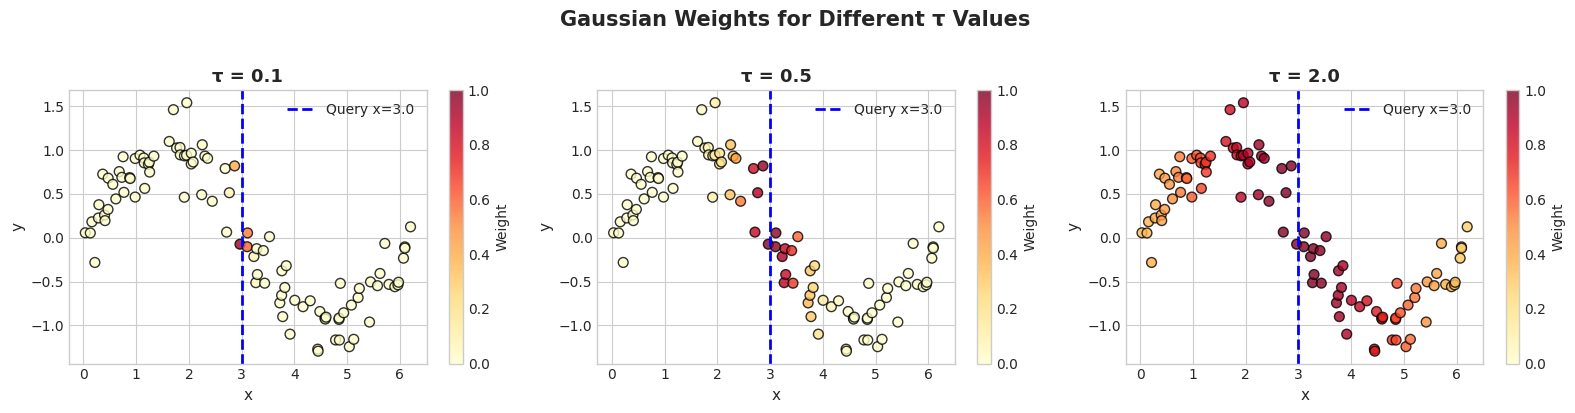

📊 Observations:
  • Small τ (0.1): Only VERY close points have significant weight
  • Medium τ (0.5): Moderate neighborhood
  • Large τ (2.0): Almost ALL points contribute equally


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

query_point = 3.0
taus = [0.1, 0.5, 2.0]

for ax, tau in zip(axes, taus):
    W = compute_weights(X_lwr, query_point, tau)
    weights = np.diag(W)
    
    # Color points by weight
    scatter = ax.scatter(X_lwr, y_lwr, c=weights, cmap='YlOrRd',
                         s=50, edgecolors='k', alpha=0.8, vmin=0, vmax=1)
    ax.axvline(x=query_point, color='blue', linestyle='--', linewidth=2, label=f'Query x={query_point}')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'τ = {tau}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.colorbar(scatter, ax=ax, label='Weight')

plt.suptitle('Gaussian Weights for Different τ Values', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 Observations:")
print("  • Small τ (0.1): Only VERY close points have significant weight")
print("  • Medium τ (0.5): Moderate neighborhood")
print("  • Large τ (2.0): Almost ALL points contribute equally")

## 1.4 Effect of Bandwidth $\tau$ on the Fit

This is the most important hyperparameter in LWR:
- **Small τ** → Overfitting (too wiggly)
- **Large τ** → Underfitting (too smooth, approaches standard linear regression)
- **Just right τ** → Good fit that captures the true pattern

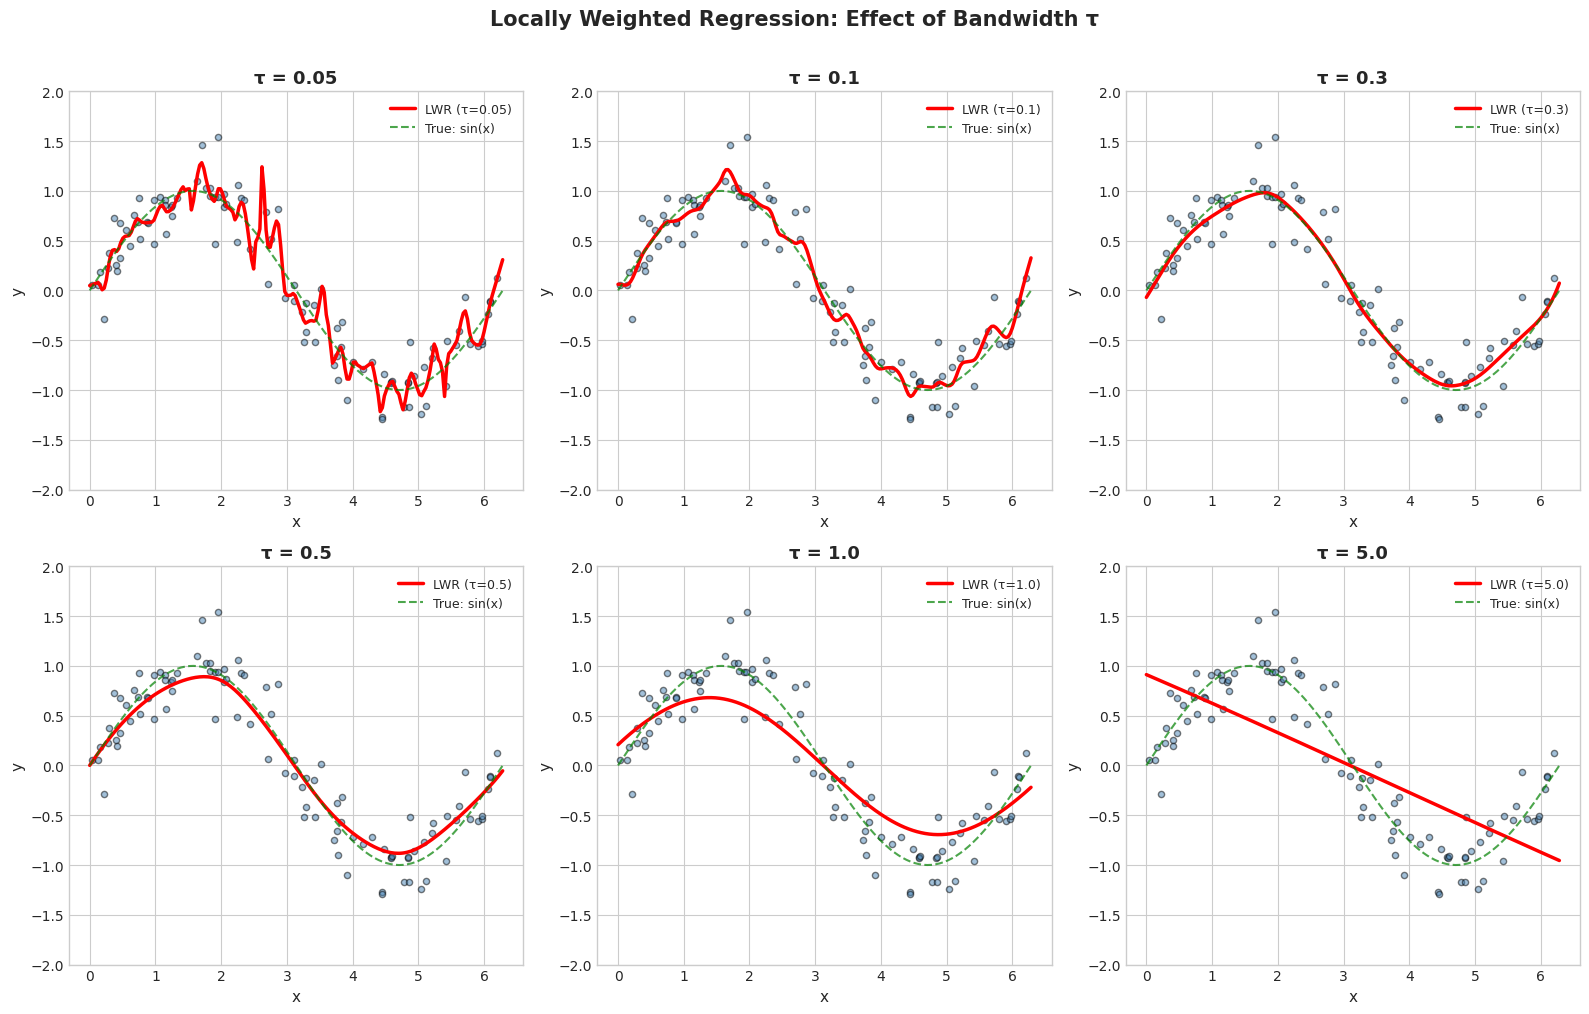

📊 Analysis:
  τ = 0.05  → OVERFITTING (too wiggly, fits noise)
  τ = 0.1   → Slight overfitting
  τ = 0.3   → ✅ GOOD FIT (captures sin curve nicely)
  τ = 0.5   → ✅ GOOD FIT (slightly smoother)
  τ = 1.0   → Starting to underfit
  τ = 5.0   → UNDERFITTING (basically a straight line)


In [29]:
X_query = np.linspace(0, 2 * np.pi, 200)
taus = [0.05, 0.1, 0.3, 0.5, 1.0, 5.0]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, tau in zip(axes, taus):
    predictions = lwr_predict(X_lwr, y_lwr, X_query, tau)
    
    ax.scatter(X_lwr, y_lwr, color='steelblue', s=20, alpha=0.5, edgecolors='k')
    ax.plot(X_query, predictions, 'r-', linewidth=2.5, label=f'LWR (τ={tau})')
    ax.plot(X_query, np.sin(X_query), 'g--', linewidth=1.5, alpha=0.7, label='True: sin(x)')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'τ = {tau}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-2, 2)

plt.suptitle('Locally Weighted Regression: Effect of Bandwidth τ',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("📊 Analysis:")
print("  τ = 0.05  → OVERFITTING (too wiggly, fits noise)")
print("  τ = 0.1   → Slight overfitting")
print("  τ = 0.3   → ✅ GOOD FIT (captures sin curve nicely)")
print("  τ = 0.5   → ✅ GOOD FIT (slightly smoother)")
print("  τ = 1.0   → Starting to underfit")
print("  τ = 5.0   → UNDERFITTING (basically a straight line)")

## 1.5 LWR vs Standard Linear Regression

Let's compare LWR against standard linear regression on our non-linear data.

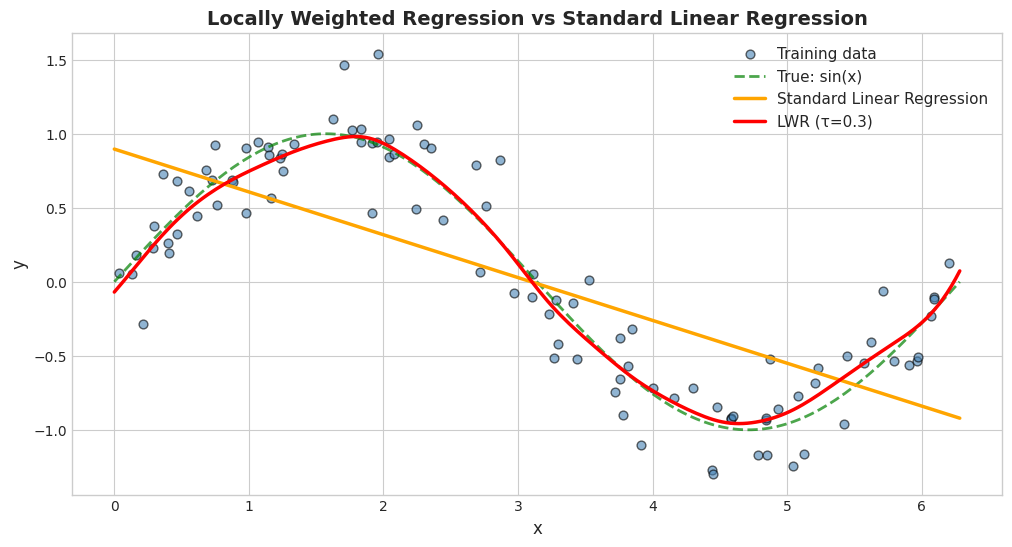

📊 LWR captures the non-linear pattern beautifully!
   Standard linear regression is completely lost here.

⚠️  Trade-off: LWR must store all training data and
   recompute for every new prediction (non-parametric).


In [30]:
# Standard Linear Regression
X_design = np.c_[np.ones(m), X_lwr]
theta_lr = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_lwr

# LWR predictions
X_query = np.linspace(0, 2 * np.pi, 200)
lwr_preds = lwr_predict(X_lwr, y_lwr, X_query, tau=0.3)

# Linear regression predictions
lr_preds = np.c_[np.ones(len(X_query)), X_query] @ theta_lr

plt.figure(figsize=(12, 6))
plt.scatter(X_lwr, y_lwr, color='steelblue', s=40, alpha=0.6, edgecolors='k', label='Training data')
plt.plot(X_query, np.sin(X_query), 'g--', linewidth=2, label='True: sin(x)', alpha=0.7)
plt.plot(X_query, lr_preds, 'orange', linewidth=2.5, label='Standard Linear Regression')
plt.plot(X_query, lwr_preds, 'r-', linewidth=2.5, label='LWR (τ=0.3)')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Locally Weighted Regression vs Standard Linear Regression',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.show()

print("📊 LWR captures the non-linear pattern beautifully!")
print("   Standard linear regression is completely lost here.")
print("\n⚠️  Trade-off: LWR must store all training data and")
print("   recompute for every new prediction (non-parametric).")

---
# Part 2: Logistic Regression (Classification)
---

## 2.1 Generate Classification Data

We'll create a binary classification dataset:
- Class 0: Students who **failed** an exam
- Class 1: Students who **passed** an exam

Features: hours studied ($x_1$) and hours slept ($x_2$)

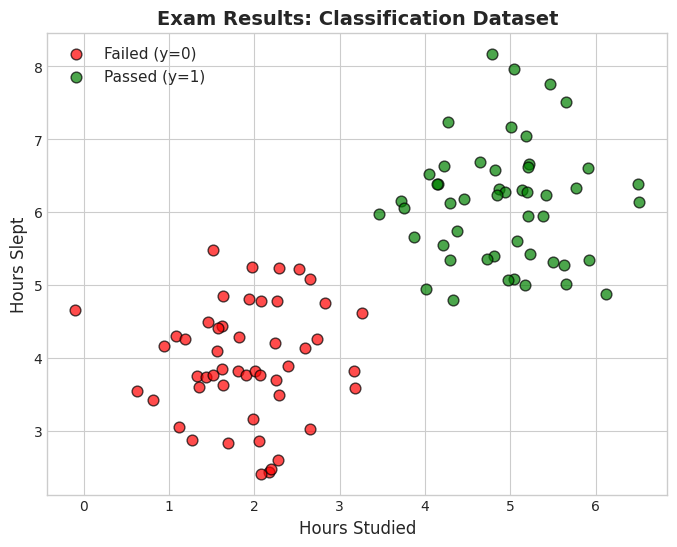

Dataset: 100 examples, 2 features
Class 0 (Failed): 50 examples
Class 1 (Passed): 50 examples


In [31]:
# Generate binary classification data
np.random.seed(42)

# Class 0 (Failed): lower study hours, variable sleep
n_class = 50
X_class0 = np.random.randn(n_class, 2) * 0.8 + np.array([2, 4])

# Class 1 (Passed): higher study hours, variable sleep
X_class1 = np.random.randn(n_class, 2) * 0.8 + np.array([5, 6])

# Combine
X_clf = np.vstack([X_class0, X_class1])
y_clf = np.concatenate([np.zeros(n_class), np.ones(n_class)])

m_clf = len(y_clf)
n_features = X_clf.shape[1]

# Shuffle
shuffle_idx = np.random.permutation(m_clf)
X_clf = X_clf[shuffle_idx]
y_clf = y_clf[shuffle_idx]

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_clf[y_clf == 0, 0], X_clf[y_clf == 0, 1],
            color='red', s=60, edgecolors='k', alpha=0.7, label='Failed (y=0)')
plt.scatter(X_clf[y_clf == 1, 0], X_clf[y_clf == 1, 1],
            color='green', s=60, edgecolors='k', alpha=0.7, label='Passed (y=1)')
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Hours Slept', fontsize=12)
plt.title('Exam Results: Classification Dataset', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.show()

print(f"Dataset: {m_clf} examples, {n_features} features")
print(f"Class 0 (Failed): {np.sum(y_clf == 0):.0f} examples")
print(f"Class 1 (Passed): {np.sum(y_clf == 1):.0f} examples")

## 2.2 Feature Normalization & Setup

Same as linear regression — normalize features and add intercept.

In [32]:
def feature_normalize(X):
    """Normalize features to mean=0, std=1"""
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalize
X_clf_norm, mu_clf, sigma_clf = feature_normalize(X_clf)

# Add intercept column
X_clf_design = np.c_[np.ones(m_clf), X_clf_norm]

print(f"Design matrix shape: {X_clf_design.shape}")
print(f"Feature means: {mu_clf.round(2)}")
print(f"Feature stds: {sigma_clf.round(2)}")
print(f"\nFirst 3 rows of design matrix:")

df_clf = pd.DataFrame(X_clf_design, columns=['x₀ (intercept)', 'x₁ (study hrs)', 'x₂ (sleep hrs)'])
df_clf.head(3)

Design matrix shape: (100, 3)
Feature means: [3.41 5.03]
Feature stds: [1.66 1.34]

First 3 rows of design matrix:


,x₀ (intercept),x₁ (study hrs),x₂ (sleep hrs)
0,1.0,1.185811,0.681298
1,1.0,-1.250715,-0.949542
2,1.0,0.034554,0.708901


## 2.3 The Sigmoid Function

The heart of logistic regression:

$$g(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- Maps any real number to $(0, 1)$
- $g(0) = 0.5$
- $g'(z) = g(z)(1 - g(z))$ ← This elegant derivative simplifies gradient computation

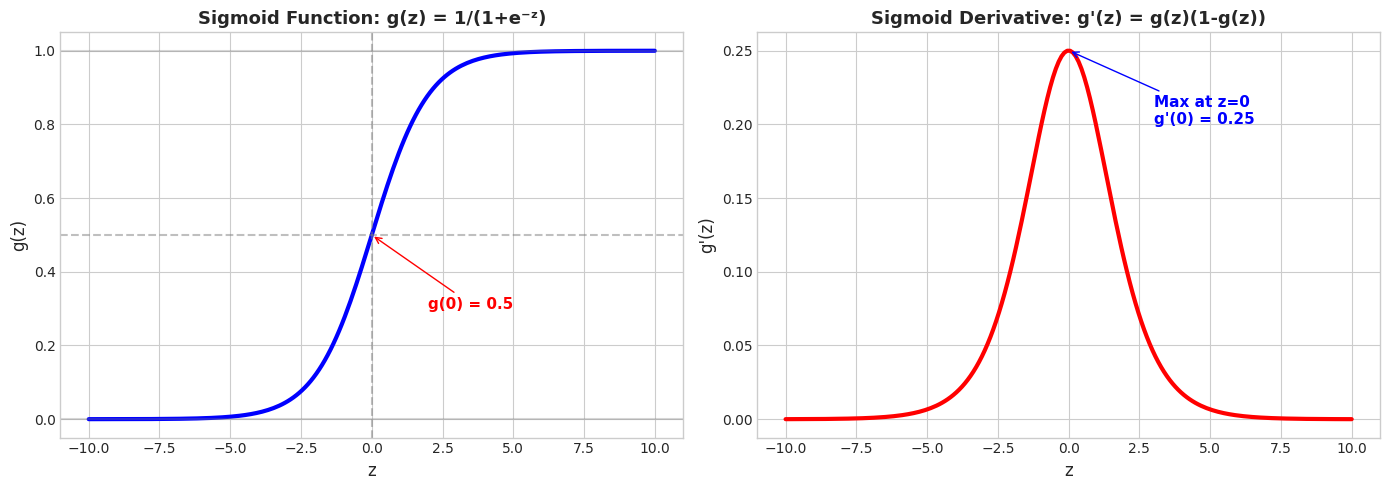

Sigmoid Properties:
  g(-∞) ≈ 0.000000  (approaches 0)
  g(0)  = 0.500000  (exactly 0.5)
  g(+∞) ≈ 1.000000  (approaches 1)
  g'(0) = 0.250000  (maximum slope)


In [33]:
def sigmoid(z):
    """
    The sigmoid (logistic) function.
    
    g(z) = 1 / (1 + exp(-z))
    
    Parameters:
        z: scalar, vector, or matrix
    
    Returns:
        g(z): same shape as z, values in (0, 1)
    """
    return 1 / (1 + np.exp(-z))


# Visualize the sigmoid
z = np.linspace(-10, 10, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sigmoid function
axes[0].plot(z, sigmoid(z), 'b-', linewidth=3)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0].axhline(y=1, color='gray', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('z', fontsize=12)
axes[0].set_ylabel('g(z)', fontsize=12)
axes[0].set_title('Sigmoid Function: g(z) = 1/(1+e⁻ᶻ)', fontsize=13, fontweight='bold')
axes[0].annotate('g(0) = 0.5', xy=(0, 0.5), xytext=(2, 0.3),
                 fontsize=11, arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontweight='bold')

# Plot 2: Sigmoid derivative
g = sigmoid(z)
g_prime = g * (1 - g)
axes[1].plot(z, g_prime, 'r-', linewidth=3)
axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel("g'(z)", fontsize=12)
axes[1].set_title("Sigmoid Derivative: g'(z) = g(z)(1-g(z))", fontsize=13, fontweight='bold')
axes[1].annotate("Max at z=0\ng'(0) = 0.25", xy=(0, 0.25), xytext=(3, 0.2),
                 fontsize=11, arrowprops=dict(arrowstyle='->', color='blue'),
                 color='blue', fontweight='bold')

plt.tight_layout()
plt.show()

# Verify key properties
print("Sigmoid Properties:")
print(f"  g(-∞) ≈ {sigmoid(-100):.6f}  (approaches 0)")
print(f"  g(0)  = {sigmoid(0):.6f}  (exactly 0.5)")
print(f"  g(+∞) ≈ {sigmoid(100):.6f}  (approaches 1)")
print(f"  g'(0) = {sigmoid(0) * (1 - sigmoid(0)):.6f}  (maximum slope)")

## 2.4 Logistic Regression: Core Functions

### Hypothesis
$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

### Cost Function (Binary Cross-Entropy / Log Loss)
$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

### Gradient
$$\nabla_\theta J(\theta) = \frac{1}{m} X^T \left(h_\theta(X) - \vec{y}\right)$$

**Note:** The gradient has the SAME form as linear regression,
but $h_\theta$ uses the sigmoid function!

In [34]:
def logistic_hypothesis(X, theta):
    """
    h_θ(x) = sigmoid(θ^T x)
    
    Parameters:
        X: (m, n+1) design matrix
        theta: (n+1,) parameter vector
    
    Returns:
        predictions: (m,) vector of probabilities in (0, 1)
    """
    return sigmoid(X @ theta)


def logistic_cost(X, y, theta):
    """
    Binary Cross-Entropy Cost Function
    
    J(θ) = -(1/m) Σ [y*log(h) + (1-y)*log(1-h)]
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) binary target vector (0 or 1)
        theta: (n+1,) parameter vector
    
    Returns:
        cost: scalar value of J(θ)
    """
    m = len(y)
    h = logistic_hypothesis(X, theta)
    
    # Clip to avoid log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    
    cost = -(1/m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )
    return cost


def logistic_gradient(X, y, theta):
    """
    Compute the gradient of the cost function
    
    ∇J(θ) = (1/m) X^T (h_θ(X) - y)
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) target vector
        theta: (n+1,) parameter vector
    
    Returns:
        gradient: (n+1,) vector
    """
    m = len(y)
    h = logistic_hypothesis(X, theta)
    gradient = (1/m) * (X.T @ (h - y))
    return gradient


# Test with initial theta = zeros
initial_theta_clf = np.zeros(n_features + 1)
initial_cost = logistic_cost(X_clf_design, y_clf, initial_theta_clf)
initial_gradient = logistic_gradient(X_clf_design, y_clf, initial_theta_clf)

print(f"Initial theta: {initial_theta_clf}")
print(f"Initial cost J(θ=0): {initial_cost:.4f}")
print(f"Initial gradient: {initial_gradient.round(4)}")
print(f"\nExpected initial cost: -log(0.5) = {-np.log(0.5):.4f}")
print(f"(Because when θ=0, all predictions = 0.5)")

Initial theta: [0. 0. 0.]
Initial cost J(θ=0): 0.6931
Initial gradient: [ 0.     -0.4561 -0.4041]

Expected initial cost: -log(0.5) = 0.6931
(Because when θ=0, all predictions = 0.5)


## 2.5 Intuition: Why This Cost Function?

Let's visualize what happens when we predict correctly vs incorrectly.

When $y = 1$: Cost = $-\log(h_\theta(x))$ → penalizes low predictions  
When $y = 0$: Cost = $-\log(1 - h_\theta(x))$ → penalizes high predictions

/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_27443/2288839598.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_27443/2288839598.py:28: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/apple/Desktop/CS229/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/apple/Desktop/CS229/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


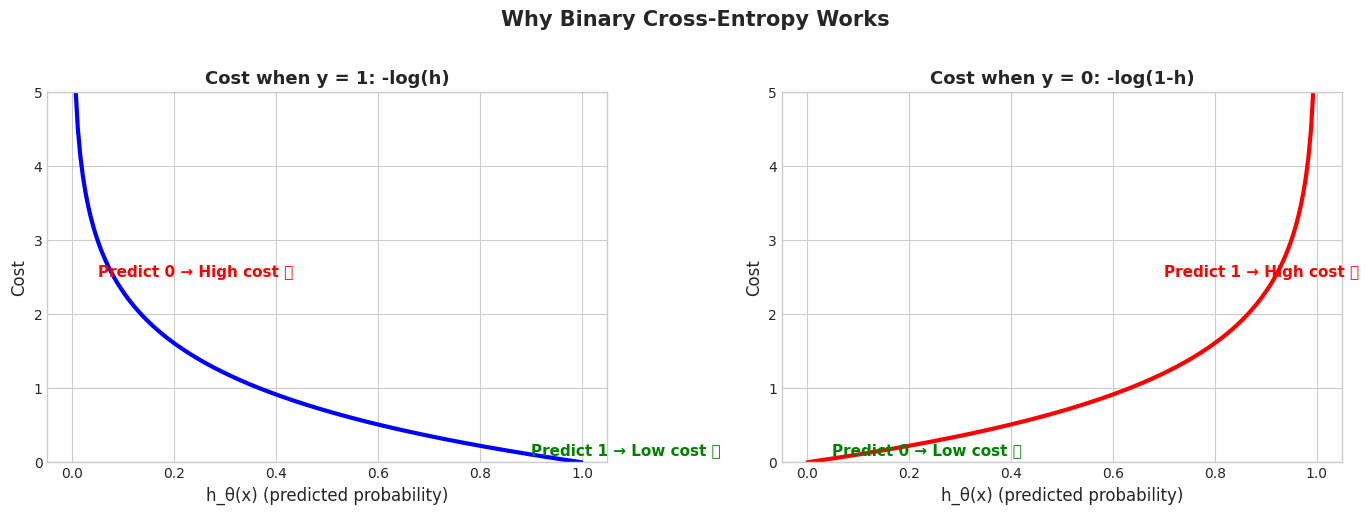

📊 Key Insight:
  The cost function gives INFINITE penalty for confident wrong predictions!
  This forces the model to be calibrated — if it's confident, it better be right.


In [35]:
h = np.linspace(0.001, 0.999, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# When y = 1
axes[0].plot(h, -np.log(h), 'b-', linewidth=3)
axes[0].set_xlabel('h_θ(x) (predicted probability)', fontsize=12)
axes[0].set_ylabel('Cost', fontsize=12)
axes[0].set_title('Cost when y = 1: -log(h)', fontsize=13, fontweight='bold')
axes[0].annotate('Predict 1 → Low cost ✅', xy=(0.9, 0.1), fontsize=11, color='green',
                 fontweight='bold')
axes[0].annotate('Predict 0 → High cost ❌', xy=(0.05, 2.5), fontsize=11, color='red',
                 fontweight='bold')
axes[0].set_ylim(0, 5)

# When y = 0
axes[1].plot(h, -np.log(1 - h), 'r-', linewidth=3)
axes[1].set_xlabel('h_θ(x) (predicted probability)', fontsize=12)
axes[1].set_ylabel('Cost', fontsize=12)
axes[1].set_title('Cost when y = 0: -log(1-h)', fontsize=13, fontweight='bold')
axes[1].annotate('Predict 0 → Low cost ✅', xy=(0.05, 0.1), fontsize=11, color='green',
                 fontweight='bold')
axes[1].annotate('Predict 1 → High cost ❌', xy=(0.7, 2.5), fontsize=11, color='red',
                 fontweight='bold')
axes[1].set_ylim(0, 5)

plt.suptitle('Why Binary Cross-Entropy Works', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 Key Insight:")
print("  The cost function gives INFINITE penalty for confident wrong predictions!")
print("  This forces the model to be calibrated — if it's confident, it better be right.")

## 2.6 Gradient Descent for Logistic Regression

The update rule looks **identical** to linear regression:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}$$

But remember: $h_\theta(x) = \text{sigmoid}(\theta^T x)$ here, not $\theta^T x$.

In [36]:
def logistic_gradient_descent(X, y, theta, alpha, num_iterations):
    """
    Gradient descent for logistic regression.
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) binary target vector
        theta: (n+1,) initial parameters
        alpha: learning rate
        num_iterations: number of iterations
    
    Returns:
        theta: optimized parameters
        cost_history: cost at each iteration
    """
    cost_history = []
    
    for i in range(num_iterations):
        # Compute gradient
        gradient = logistic_gradient(X, y, theta)
        
        # Update
        theta = theta - alpha * gradient
        
        # Track cost
        cost = logistic_cost(X, y, theta)
        cost_history.append(cost)
    
    return theta, cost_history


# Train!
print("Training Logistic Regression with Gradient Descent...")
print(f"Learning rate α = 1")
print(f"Iterations = 5000\n")

theta_gd, cost_history_gd = logistic_gradient_descent(
    X_clf_design, y_clf,
    theta=np.zeros(n_features + 1),
    alpha=1,
    num_iterations=5000
)

print(f"Optimized θ: {np.round(theta_gd, 4)}")
print(f"  θ₀ (intercept):  {theta_gd[0]:.4f}")
print(f"  θ₁ (study hrs):  {theta_gd[1]:.4f}")
print(f"  θ₂ (sleep hrs):  {theta_gd[2]:.4f}")
print(f"\nFinal cost: {cost_history_gd[-1]:.6f}")

# Compute accuracy
predictions_gd = (logistic_hypothesis(X_clf_design, theta_gd) >= 0.5).astype(int)
accuracy_gd = np.mean(predictions_gd == y_clf) * 100
print(f"Training accuracy: {accuracy_gd:.1f}%")

Training Logistic Regression with Gradient Descent...
Learning rate α = 1
Iterations = 5000

Optimized θ: [-0.2115 10.2082  6.0481]
  θ₀ (intercept):  -0.2115
  θ₁ (study hrs):  10.2082
  θ₂ (sleep hrs):  6.0481

Final cost: 0.001573
Training accuracy: 100.0%


---
# Part 3: Newton's Method
---

## 3.1 The Idea

Gradient descent is a **first-order** method (uses only the gradient).  
Newton's method is a **second-order** method (uses gradient AND curvature).

**Update rule:**
$$\theta := \theta - H^{-1} \nabla_\theta J(\theta)$$

where $H$ is the **Hessian matrix** (matrix of second partial derivatives):

$$H_{jk} = \frac{\partial^2 J(\theta)}{\partial \theta_j \partial \theta_k}$$

### For Logistic Regression:

$$H = \frac{1}{m} X^T S X$$

where $S$ is a diagonal matrix with:

$$S_{ii} = h_\theta(x^{(i)}) \cdot (1 - h_\theta(x^{(i)}))$$

This is because $g'(z) = g(z)(1-g(z))$.

### Why Newton's Method is Faster

- Gradient descent takes many small steps in the steepest direction
- Newton's method uses **curvature information** to take smarter, larger steps
- It has **quadratic convergence**: the number of correct digits roughly **doubles** each iteration
- Typically converges in **5-15 iterations** (vs hundreds/thousands for GD)

### The Trade-off

| | Gradient Descent | Newton's Method |
|--|---|---|
| Per-iteration cost | $O(mn)$ | $O(mn^2 + n^3)$ |
| Iterations needed | Hundreds/thousands | ~5-15 |
| Memory | $O(n)$ | $O(n^2)$ for Hessian |
| Scalability | Good for large $n$ | Impractical for very large $n$ |

In [37]:
def logistic_hessian(X, y, theta):
    """
    Compute the Hessian matrix for logistic regression.
    
    H = (1/m) X^T S X
    
    where S is diagonal with S_ii = h(x_i) * (1 - h(x_i))
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) target vector (not used in computation, included for API consistency)
        theta: (n+1,) parameter vector
    
    Returns:
        H: (n+1, n+1) Hessian matrix
    """
    m = len(y)
    h = logistic_hypothesis(X, theta)
    
    # S is diagonal: S_ii = h_i * (1 - h_i)
    s = h * (1 - h)
    S = np.diag(s)
    
    # Hessian
    H = (1/m) * (X.T @ S @ X)
    
    return H


def newtons_method(X, y, theta, num_iterations):
    """
    Newton's Method for logistic regression.
    
    θ := θ - H⁻¹ ∇J(θ)
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) binary target vector
        theta: (n+1,) initial parameters
        num_iterations: number of iterations
    
    Returns:
        theta: optimized parameters
        cost_history: cost at each iteration
    """
    cost_history = []
    
    for i in range(num_iterations):
        # Compute gradient
        gradient = logistic_gradient(X, y, theta)
        
        # Compute Hessian
        H = logistic_hessian(X, y, theta)
        
        # Newton's update: θ := θ - H⁻¹ ∇J
        theta = theta - np.linalg.inv(H) @ gradient
        
        # Track cost
        cost = logistic_cost(X, y, theta)
        cost_history.append(cost)
        
        print(f"  Iteration {i+1}: Cost = {cost:.8f}")
    
    return theta, cost_history


# Train with Newton's Method!
print("Training Logistic Regression with Newton's Method...")
print(f"Iterations: Just 10!\n")

theta_newton, cost_history_newton = newtons_method(
    X_clf_design, y_clf,
    theta=np.zeros(n_features + 1),
    num_iterations=10
)

print(f"\nOptimized θ (Newton): {np.round(theta_newton, 4)}")
print(f"Final cost: {cost_history_newton[-1]:.8f}")

# Compute accuracy
predictions_newton = (logistic_hypothesis(X_clf_design, theta_newton) >= 0.5).astype(int)
accuracy_newton = np.mean(predictions_newton == y_clf) * 100
print(f"Training accuracy: {accuracy_newton:.1f}%")

Training Logistic Regression with Newton's Method...
Iterations: Just 10!

  Iteration 1: Cost = 0.19135040
  Iteration 2: Cost = 0.08736091
  Iteration 3: Cost = 0.04251238
  Iteration 4: Cost = 0.02084737
  Iteration 5: Cost = 0.00994696
  Iteration 6: Cost = 0.00453799
  Iteration 7: Cost = 0.00197440
  Iteration 8: Cost = 0.00082301
  Iteration 9: Cost = 0.00033123
  Iteration 10: Cost = 0.00012972

Optimized θ (Newton): [-0.598  18.1357  9.5   ]
Final cost: 0.00012972
Training accuracy: 100.0%


## 3.2 Newton's Method vs Gradient Descent: Convergence Comparison

Newton's method should converge in **far fewer iterations**.
Let's visualize this dramatic difference.

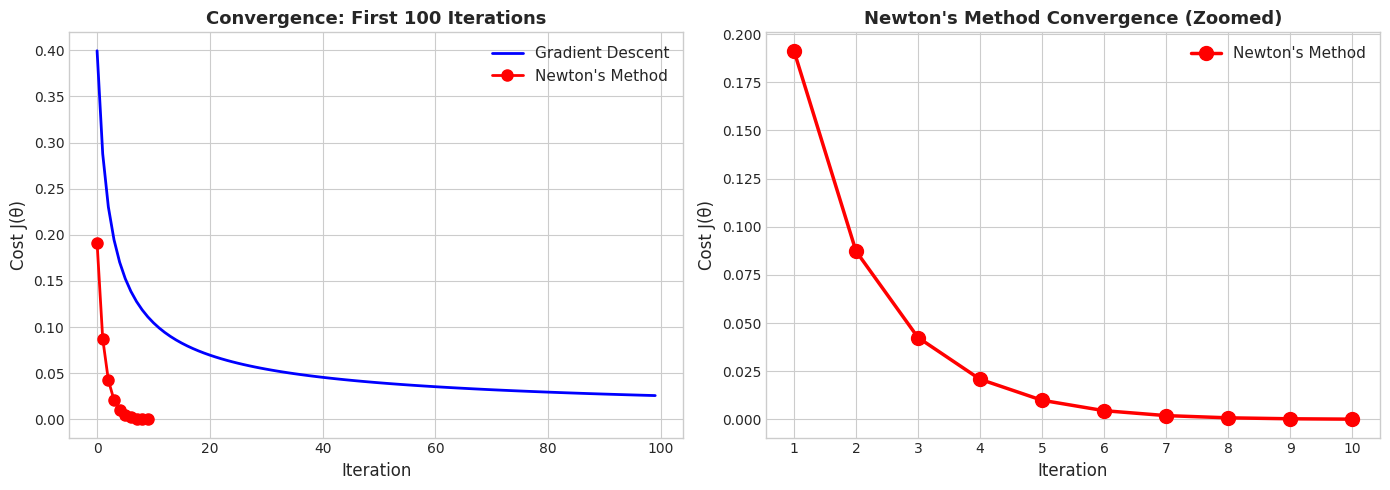

📊 Dramatic Difference:
  Gradient Descent after 1000 iterations: Cost = 0.00157315
  Newton's Method after 10 iterations:    Cost = 0.00012972

  Newton's method converges in ~5 iterations!
  This is QUADRATIC convergence — digits of accuracy roughly double each step.


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Both on same plot
axes[0].plot(cost_history_gd[:100], 'b-', linewidth=2, label='Gradient Descent')
axes[0].plot(cost_history_newton, 'r-o', linewidth=2, markersize=8, label="Newton's Method")
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost J(θ)', fontsize=12)
axes[0].set_title('Convergence: First 100 Iterations', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# Plot 2: Zoom into Newton's method
axes[1].plot(range(1, len(cost_history_newton) + 1), cost_history_newton,
             'r-o', linewidth=2.5, markersize=10, label="Newton's Method")
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Cost J(θ)', fontsize=12)
axes[1].set_title("Newton's Method Convergence (Zoomed)", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xticks(range(1, len(cost_history_newton) + 1))

plt.tight_layout()
plt.show()

print("📊 Dramatic Difference:")
print(f"  Gradient Descent after 1000 iterations: Cost = {cost_history_gd[-1]:.8f}")
print(f"  Newton's Method after 10 iterations:    Cost = {cost_history_newton[-1]:.8f}")
print(f"\n  Newton's method converges in ~5 iterations!")
print(f"  This is QUADRATIC convergence — digits of accuracy roughly double each step.")

## 3.3 Side-by-Side Parameter Comparison

Both methods should converge to (approximately) the same optimal θ.

In [39]:
print("=" * 55)
print("PARAMETER COMPARISON")
print("=" * 55)
print(f"{'Parameter':<12} {'Gradient Descent':>18} {'Newton Method':>18}")
print("-" * 55)
print(f"{'θ₀':<12} {theta_gd[0]:>18.6f} {theta_newton[0]:>18.6f}")
print(f"{'θ₁':<12} {theta_gd[1]:>18.6f} {theta_newton[1]:>18.6f}")
print(f"{'θ₂':<12} {theta_gd[2]:>18.6f} {theta_newton[2]:>18.6f}")
print("-" * 55)
print(f"{'Cost':<12} {cost_history_gd[-1]:>18.6f} {cost_history_newton[-1]:>18.6f}")
print(f"{'Accuracy':<12} {accuracy_gd:>17.1f}% {accuracy_newton:>17.1f}%")
print(f"{'Iterations':<12} {'1000':>18} {'10':>18}")
print("=" * 55)

# Check if they converged to the same solution
diff = np.linalg.norm(theta_gd - theta_newton)
print(f"\n‖θ_GD - θ_Newton‖ = {diff:.6f}")
if diff < 0.01:
    print("✅ Both methods converged to the SAME solution!")
else:
    print("⚠️  GD may need more iterations to fully converge to Newton's solution")

PARAMETER COMPARISON
Parameter      Gradient Descent      Newton Method
-------------------------------------------------------
θ₀                    -0.211503          -0.598007
θ₁                    10.208209          18.135728
θ₂                     6.048101           9.499962
-------------------------------------------------------
Cost                   0.001573           0.000130
Accuracy                 100.0%             100.0%
Iterations                 1000                 10

‖θ_GD - θ_Newton‖ = 8.655073
⚠️  GD may need more iterations to fully converge to Newton's solution


## 3.4 Decision Boundary Visualization

The decision boundary is where $h_\theta(x) = 0.5$, which means $\theta^T x = 0$.

$$\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$$

Solving for $x_2$:

$$x_2 = -\frac{\theta_0}{\theta_2} - \frac{\theta_1}{\theta_2} x_1$$

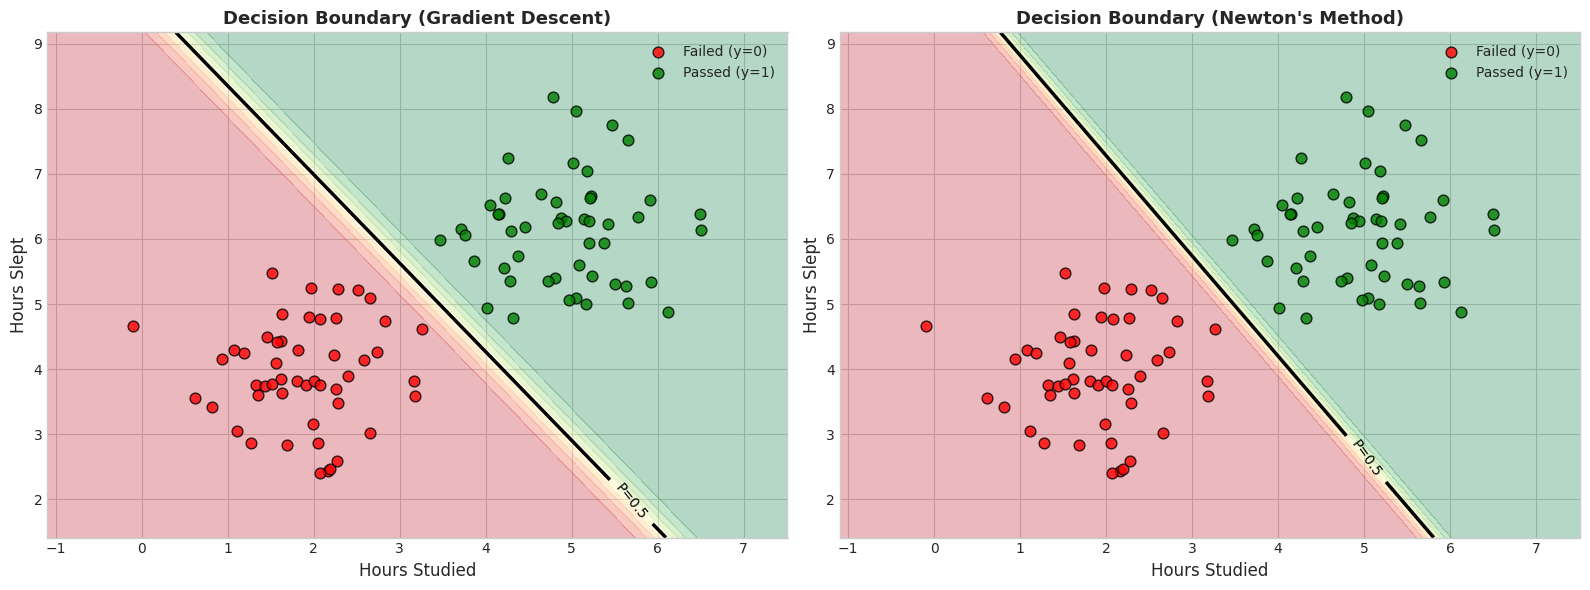

📊 Both methods produce the same decision boundary!
   The black line is where P(pass) = 0.5
   Green region: model predicts PASS
   Red region: model predicts FAIL


In [40]:
def plot_decision_boundary(X_raw, y, theta, mu, sigma, title, ax):
    """
    Plot the decision boundary on the original (un-normalized) feature space.
    """
    # Create mesh grid in raw feature space
    x1_min, x1_max = X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1
    x2_min, x2_max = X_raw[:, 1].min() - 1, X_raw[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 200),
        np.linspace(x2_min, x2_max, 200)
    )
    
    # Normalize mesh points using training statistics
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    grid_norm = (grid_points - mu) / sigma
    grid_design = np.c_[np.ones(len(grid_norm)), grid_norm]
    
    # Get predictions
    probs = logistic_hypothesis(grid_design, theta)
    probs = probs.reshape(xx1.shape)
    
    # Plot decision boundary and probability contours
    ax.contourf(xx1, xx2, probs, levels=np.linspace(0, 1, 11),
                cmap='RdYlGn', alpha=0.3)
    contour = ax.contour(xx1, xx2, probs, levels=[0.5],
                          colors='black', linewidths=2.5)
    ax.clabel(contour, fmt='P=%.1f', fontsize=10)
    
    # Plot data points
    ax.scatter(X_raw[y == 0, 0], X_raw[y == 0, 1],
               color='red', s=60, edgecolors='k', alpha=0.8, label='Failed (y=0)')
    ax.scatter(X_raw[y == 1, 0], X_raw[y == 1, 1],
               color='green', s=60, edgecolors='k', alpha=0.8, label='Passed (y=1)')
    
    ax.set_xlabel('Hours Studied', fontsize=12)
    ax.set_ylabel('Hours Slept', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(X_clf, y_clf, theta_gd, mu_clf, sigma_clf,
                       'Decision Boundary (Gradient Descent)', axes[0])
plot_decision_boundary(X_clf, y_clf, theta_newton, mu_clf, sigma_clf,
                       "Decision Boundary (Newton's Method)", axes[1])

plt.tight_layout()
plt.show()

print("📊 Both methods produce the same decision boundary!")
print("   The black line is where P(pass) = 0.5")
print("   Green region: model predicts PASS")
print("   Red region: model predicts FAIL")

## 3.5 Prediction Pipeline

Let's make predictions for new students!
"""

In [41]:
def predict_student(features, theta, mu, sigma):
    """
    Predict pass/fail probability for a new student.
    
    Parameters:
        features: [hours_studied, hours_slept] (raw, un-normalized)
        theta: trained parameters
        mu: training feature means
        sigma: training feature stds
    
    Returns:
        probability: P(pass)
        prediction: 0 (fail) or 1 (pass)
    """
    features_norm = (features - mu) / sigma
    x = np.concatenate([[1], features_norm])
    prob = sigmoid(x @ theta)
    prediction = 1 if prob >= 0.5 else 0
    return prob, prediction


# Test students
test_students = [
    [2, 3],    # Low study, low sleep
    [5, 6],    # High study, good sleep
    [3.5, 5],  # Moderate (near boundary)
    [6, 7],    # Very high study + sleep
    [1, 2],    # Barely studied, barely slept
    [4, 5.5],  # Right on the edge
]

print("=" * 70)
print("STUDENT EXAM PREDICTIONS (Newton's Method Model)")
print("=" * 70)
print(f"{'Study Hrs':>10} {'Sleep Hrs':>10} {'P(Pass)':>10} {'Prediction':>12}")
print("-" * 70)

for student in test_students:
    prob, pred = predict_student(np.array(student), theta_newton, mu_clf, sigma_clf)
    status = "✅ PASS" if pred == 1 else "❌ FAIL"
    confidence = "High" if abs(prob - 0.5) > 0.3 else "Low" if abs(prob - 0.5) < 0.1 else "Medium"
    print(f"{student[0]:>10.1f} {student[1]:>10.1f} {prob:>10.4f} {status:>12}  ({confidence} confidence)")

print("-" * 70)

STUDENT EXAM PREDICTIONS (Newton's Method Model)
 Study Hrs  Sleep Hrs    P(Pass)   Prediction
----------------------------------------------------------------------
       2.0        3.0     0.0000       ❌ FAIL  (High confidence)
       5.0        6.0     1.0000       ✅ PASS  (High confidence)
       3.5        5.0     0.5543       ✅ PASS  (Low confidence)
       6.0        7.0     1.0000       ✅ PASS  (High confidence)
       1.0        2.0     0.0000       ❌ FAIL  (High confidence)
       4.0        5.5     0.9999       ✅ PASS  (High confidence)
----------------------------------------------------------------------


## 3.6 Newton's Method Step-by-Step Visualization

Let's trace exactly what Newton's method does at each iteration:
the gradient, the Hessian, and the update step.

In [42]:
print("=" * 70)
print("NEWTON'S METHOD — STEP BY STEP TRACE")
print("=" * 70)

theta_trace = np.zeros(n_features + 1)

for i in range(6):
    # Current state
    cost = logistic_cost(X_clf_design, y_clf, theta_trace)
    grad = logistic_gradient(X_clf_design, y_clf, theta_trace)
    H = logistic_hessian(X_clf_design, y_clf, theta_trace)
    
    print(f"\n--- Iteration {i+1} ---")
    print(f"  θ = {np.round(theta_trace, 4)}")
    print(f"  Cost J(θ) = {cost:.8f}")
    print(f"  Gradient ∇J = {np.round(grad, 6)}")
    print(f"  ‖∇J‖ = {np.linalg.norm(grad):.8f}")
    print(f"  Hessian H:")
    for row in H:
        print(f"    [{', '.join(f'{v:>8.4f}' for v in row)}]")
    
    # Newton's update
    update = np.linalg.inv(H) @ grad
    print(f"  Update H⁻¹∇J = {np.round(update, 4)}")
    
    theta_trace = theta_trace - update
    
    # Check convergence
    if np.linalg.norm(grad) < 1e-8:
        print(f"\n  ✅ CONVERGED at iteration {i+1}!")
        print(f"  Gradient norm = {np.linalg.norm(grad):.2e} < 1e-8")
        break

print(f"\n  Final θ = {np.round(theta_trace, 6)}")
print(f"  Final cost = {logistic_cost(X_clf_design, y_clf, theta_trace):.8f}")

NEWTON'S METHOD — STEP BY STEP TRACE

--- Iteration 1 ---
  θ = [0. 0. 0.]
  Cost J(θ) = 0.69314718
  Gradient ∇J = [ 0.       -0.456052 -0.404089]
  ‖∇J‖ = 0.60932054
  Hessian H:
    [  0.2500,   0.0000,   0.0000]
    [  0.0000,   0.2500,   0.1861]
    [  0.0000,   0.1861,   0.2500]
  Update H⁻¹∇J = [ 0.     -1.3928 -0.5796]

--- Iteration 2 ---
  θ = [-0.      1.3928  0.5796]
  Cost J(θ) = 0.19135040
  Gradient ∇J = [-0.000675 -0.122535 -0.108492]
  ‖∇J‖ = 0.16366422
  Hessian H:
    [  0.1319,  -0.0007,   0.0009]
    [ -0.0007,   0.0974,   0.0693]
    [  0.0009,   0.0693,   0.1011]
  Update H⁻¹∇J = [-0.0074 -0.9659 -0.4113]

--- Iteration 3 ---
  θ = [0.0074 2.3587 0.991 ]
  Cost J(θ) = 0.08736091
  Gradient ∇J = [-7.0000e-06 -4.6867e-02 -4.1922e-02]
  ‖∇J‖ = 0.06288043
  Hessian H:
    [  0.0668,  -0.0007,   0.0021]
    [ -0.0007,   0.0345,   0.0225]
    [  0.0021,   0.0225,   0.0374]
  Update H⁻¹∇J = [ 0.004  -1.0348 -0.4992]

--- Iteration 4 ---
  θ = [0.0034 3.3935 1.4901]
  Co

## 3.7 Understanding Quadratic Convergence

Newton's method has **quadratic convergence**, meaning the error roughly
squares (i.e., doubles in the number of correct digits) at each iteration.

Let's verify this by looking at how the gradient norm decreases.

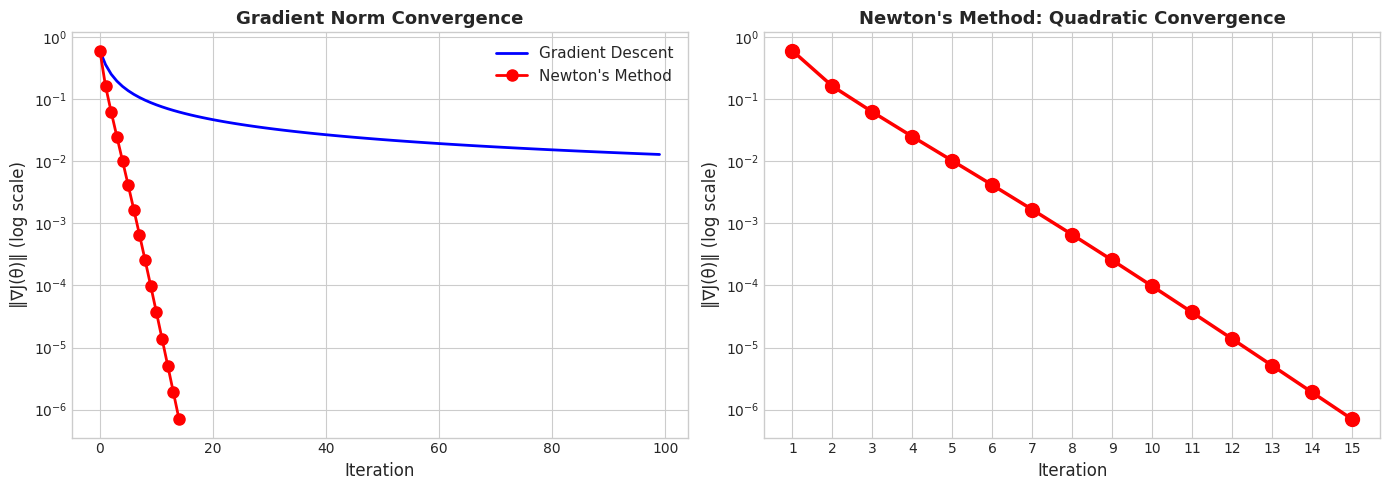

Newton's Method — Gradient Norm at Each Iteration:
---------------------------------------------
  Iteration 1: ‖∇J‖ = 6.09e-01
  Iteration 2: ‖∇J‖ = 1.64e-01
  Iteration 3: ‖∇J‖ = 6.29e-02
  Iteration 4: ‖∇J‖ = 2.52e-02
  Iteration 5: ‖∇J‖ = 1.03e-02
  Iteration 6: ‖∇J‖ = 4.17e-03
  Iteration 7: ‖∇J‖ = 1.67e-03
  Iteration 8: ‖∇J‖ = 6.60e-04
  Iteration 9: ‖∇J‖ = 2.56e-04
  Iteration 10: ‖∇J‖ = 9.77e-05
  Iteration 11: ‖∇J‖ = 3.68e-05
  Iteration 12: ‖∇J‖ = 1.38e-05
  Iteration 13: ‖∇J‖ = 5.12e-06
  Iteration 14: ‖∇J‖ = 1.90e-06
  Iteration 15: ‖∇J‖ = 7.00e-07

Gradient Descent — Gradient Norm:
  After 10 iterations:   ‖∇J‖ = 8.88e-02
  After 100 iterations:  ‖∇J‖ = 1.30e-02
  After 1000 iterations: ‖∇J‖ = 1.98e-03


In [43]:
# Run Newton's method and track gradient norms
theta_conv = np.zeros(n_features + 1)
grad_norms_newton = []
costs_newton_detailed = []

for i in range(15):
    grad = logistic_gradient(X_clf_design, y_clf, theta_conv)
    H = logistic_hessian(X_clf_design, y_clf, theta_conv)
    
    grad_norm = np.linalg.norm(grad)
    cost = logistic_cost(X_clf_design, y_clf, theta_conv)
    
    grad_norms_newton.append(grad_norm)
    costs_newton_detailed.append(cost)
    
    if grad_norm < 1e-15:
        break
    
    theta_conv = theta_conv - np.linalg.inv(H) @ grad

# Also track gradient descent for comparison
theta_gd_track = np.zeros(n_features + 1)
grad_norms_gd = []

for i in range(1000):
    grad = logistic_gradient(X_clf_design, y_clf, theta_gd_track)
    grad_norms_gd.append(np.linalg.norm(grad))
    theta_gd_track = theta_gd_track - 1.0 * grad

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gradient norm (log scale)
axes[0].semilogy(grad_norms_gd[:100], 'b-', linewidth=2, label='Gradient Descent')
axes[0].semilogy(grad_norms_newton, 'r-o', linewidth=2, markersize=8, label="Newton's Method")
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('‖∇J(θ)‖ (log scale)', fontsize=12)
axes[0].set_title('Gradient Norm Convergence', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# Plot 2: Newton's gradient norm alone (showing quadratic convergence)
axes[1].semilogy(range(1, len(grad_norms_newton) + 1), grad_norms_newton,
                 'r-o', linewidth=2.5, markersize=10)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('‖∇J(θ)‖ (log scale)', fontsize=12)
axes[1].set_title("Newton's Method: Quadratic Convergence", fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, len(grad_norms_newton) + 1))

plt.tight_layout()
plt.show()

# Print convergence rates
print("Newton's Method — Gradient Norm at Each Iteration:")
print("-" * 45)
for i, gn in enumerate(grad_norms_newton):
    print(f"  Iteration {i+1}: ‖∇J‖ = {gn:.2e}")

print(f"\nGradient Descent — Gradient Norm:")
print(f"  After 10 iterations:   ‖∇J‖ = {grad_norms_gd[9]:.2e}")
print(f"  After 100 iterations:  ‖∇J‖ = {grad_norms_gd[99]:.2e}")
print(f"  After 1000 iterations: ‖∇J‖ = {grad_norms_gd[-1]:.2e}")

## 3.8 Geometric Intuition: Why Newton's Method Works Better

Newton's method approximates the cost function with a **quadratic** (parabola)
at each step, then jumps to the minimum of that quadratic.

Gradient descent only uses the **slope** (first derivative).
Newton's method uses both the **slope** and the **curvature** (second derivative).

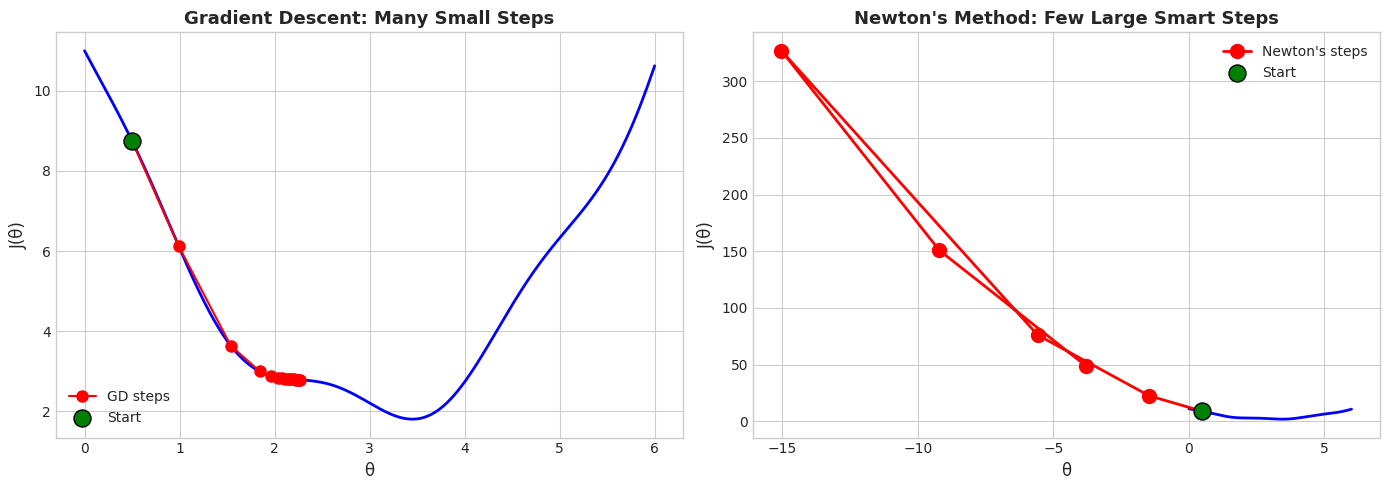

📊 Newton's method takes FEWER but SMARTER steps
   It uses curvature information to determine step size automatically


In [44]:
# 1D example for visualization
def f(x):
    """Example non-quadratic function"""
    return (x - 3)**2 + 0.5 * np.sin(3 * x) + 2

def f_prime(x):
    """First derivative"""
    return 2 * (x - 3) + 1.5 * np.cos(3 * x)

def f_double_prime(x):
    """Second derivative"""
    return 2 - 4.5 * np.sin(3 * x)


x_range = np.linspace(0, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Gradient Descent ===
ax = axes[0]
ax.plot(x_range, f(x_range), 'b-', linewidth=2)

x_gd = 0.5  # Starting point
alpha_demo = 0.1
gd_path = [x_gd]

for _ in range(15):
    x_gd = x_gd - alpha_demo * f_prime(x_gd)
    gd_path.append(x_gd)

gd_path = np.array(gd_path)
ax.plot(gd_path, f(gd_path), 'ro-', markersize=8, linewidth=1.5, label='GD steps')
ax.scatter(gd_path[0], f(gd_path[0]), color='green', s=150, zorder=5, edgecolors='k', label='Start')
ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('J(θ)', fontsize=12)
ax.set_title('Gradient Descent: Many Small Steps', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# === Newton's Method ===
ax = axes[1]
ax.plot(x_range, f(x_range), 'b-', linewidth=2)

x_nm = 0.5  # Same starting point
nm_path = [x_nm]

for _ in range(5):
    grad = f_prime(x_nm)
    hess = f_double_prime(x_nm)
    if abs(hess) > 1e-10:
        x_nm = x_nm - grad / hess
    nm_path.append(x_nm)

nm_path = np.array(nm_path)
ax.plot(nm_path, f(nm_path), 'ro-', markersize=10, linewidth=2, label="Newton's steps")
ax.scatter(nm_path[0], f(nm_path[0]), color='green', s=150, zorder=5, edgecolors='k', label='Start')
ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('J(θ)', fontsize=12)
ax.set_title("Newton's Method: Few Large Smart Steps", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Newton's method takes FEWER but SMARTER steps")
print("   It uses curvature information to determine step size automatically")

## 4. Comprehensive Model Evaluation

Let's evaluate everything together with proper metrics.

In [45]:
def compute_metrics(X, y, theta):
    """
    Compute classification metrics.
    """
    probs = logistic_hypothesis(X, theta)
    predictions = (probs >= 0.5).astype(int)
    
    tp = np.sum((predictions == 1) & (y == 1))
    tn = np.sum((predictions == 0) & (y == 0))
    fp = np.sum((predictions == 1) & (y == 0))
    fn = np.sum((predictions == 0) & (y == 1))
    
    accuracy = (tp + tn) / len(y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
    }


# Compute metrics for both methods
metrics_gd = compute_metrics(X_clf_design, y_clf, theta_gd)
metrics_newton = compute_metrics(X_clf_design, y_clf, theta_newton)

print("=" * 60)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)

print(f"\n{'Metric':<20} {'Gradient Descent':>18} {'Newton Method':>18}")
print("-" * 60)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    print(f"{metric.capitalize():<20} {metrics_gd[metric]:>18.4f} {metrics_newton[metric]:>18.4f}")

print(f"\n{'':>20} {'Gradient Descent':>18} {'Newton Method':>18}")
print("-" * 60)
print(f"{'True Positives':<20} {metrics_gd['tp']:>18.0f} {metrics_newton['tp']:>18.0f}")
print(f"{'True Negatives':<20} {metrics_gd['tn']:>18.0f} {metrics_newton['tn']:>18.0f}")
print(f"{'False Positives':<20} {metrics_gd['fp']:>18.0f} {metrics_newton['fp']:>18.0f}")
print(f"{'False Negatives':<20} {metrics_gd['fn']:>18.0f} {metrics_newton['fn']:>18.0f}")
print("-" * 60)

COMPREHENSIVE MODEL EVALUATION

Metric                 Gradient Descent      Newton Method
------------------------------------------------------------
Accuracy                         1.0000             1.0000
Precision                        1.0000             1.0000
Recall                           1.0000             1.0000
F1                               1.0000             1.0000

                       Gradient Descent      Newton Method
------------------------------------------------------------
True Positives                       50                 50
True Negatives                       50                 50
False Positives                       0                  0
False Negatives                       0                  0
------------------------------------------------------------


## 5. Confusion Matrix Visualization

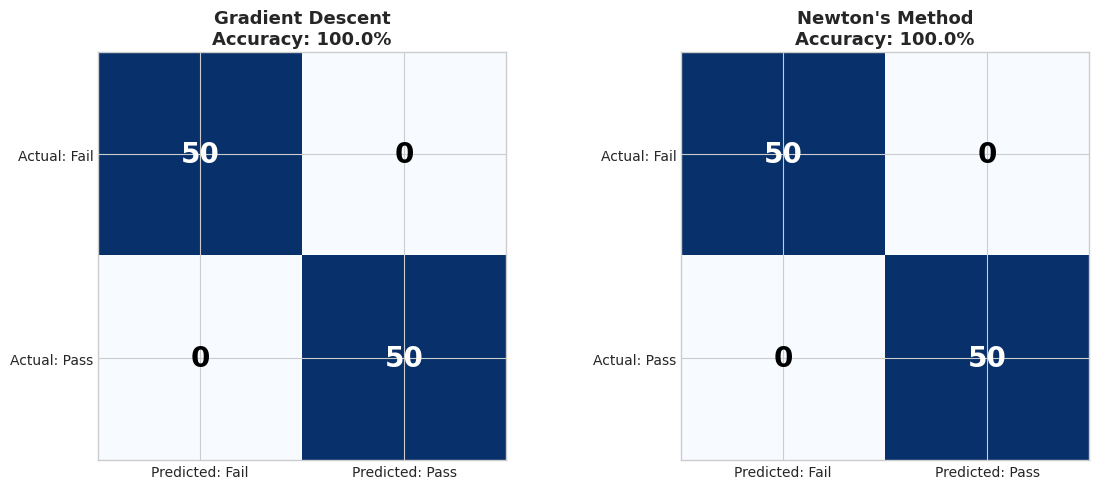

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, theta, title in [
    (axes[0], theta_gd, 'Gradient Descent'),
    (axes[1], theta_newton, "Newton's Method")
]:
    metrics = compute_metrics(X_clf_design, y_clf, theta)
    cm = np.array([[metrics['tn'], metrics['fp']],
                    [metrics['fn'], metrics['tp']]])
    
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=m_clf//2)
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > m_clf//4 else 'black'
            ax.text(j, i, f'{cm[i, j]:.0f}', ha='center', va='center',
                    fontsize=20, fontweight='bold', color=color)
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted: Fail', 'Predicted: Pass'], fontsize=10)
    ax.set_yticklabels(['Actual: Fail', 'Actual: Pass'], fontsize=10)
    ax.set_title(f'{title}\nAccuracy: {metrics["accuracy"]*100:.1f}%',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Probability Distribution Visualization

Let's see how the model's predicted probabilities are distributed
for each class.

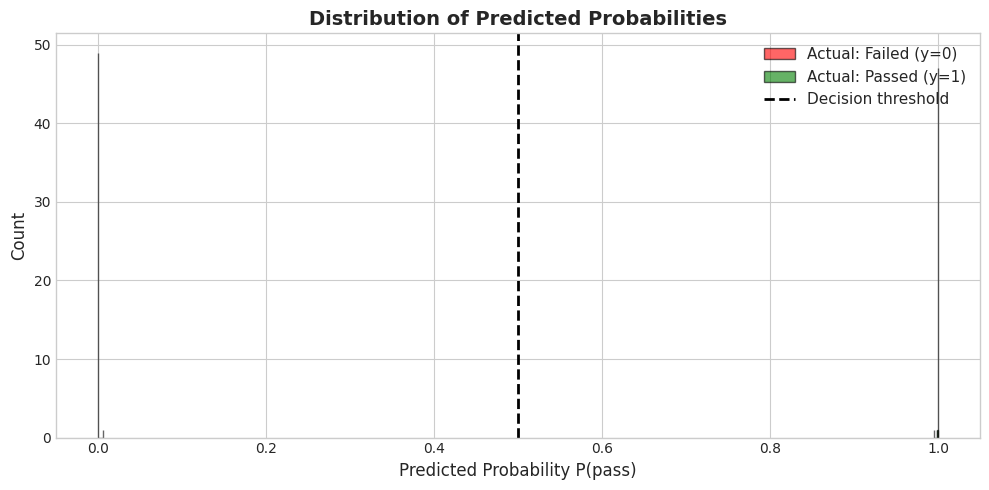

📊 A well-trained model should show:
  • Failed students (red) clustered near P=0
  • Passed students (green) clustered near P=1
  • Minimal overlap around the 0.5 threshold


In [47]:
probs_newton = logistic_hypothesis(X_clf_design, theta_newton)

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram for each class
ax.hist(probs_newton[y_clf == 0], bins=15, alpha=0.6, color='red',
        edgecolor='k', label='Actual: Failed (y=0)')
ax.hist(probs_newton[y_clf == 1], bins=15, alpha=0.6, color='green',
        edgecolor='k', label='Actual: Passed (y=1)')

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision threshold')
ax.set_xlabel('Predicted Probability P(pass)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("📊 A well-trained model should show:")
print("  • Failed students (red) clustered near P=0")
print("  • Passed students (green) clustered near P=1")
print("  • Minimal overlap around the 0.5 threshold")

---
## 7. Summary & Key Takeaways

### Part 1: Locally Weighted Regression

| Concept | Key Point |
|---------|-----------|
| **Type** | Non-parametric (keeps all training data) |
| **Key parameter** | Bandwidth τ controls locality |
| **Small τ** | Overfitting (too wiggly) |
| **Large τ** | Underfitting (too smooth) |
| **Strength** | Handles non-linear relationships without choosing features |
| **Weakness** | Expensive at prediction time, doesn't scale well |

### Part 2: Logistic Regression

| Concept | Key Point |
|---------|-----------|
| **Purpose** | Binary classification |
| **Hypothesis** | $h_\theta(x) = \text{sigmoid}(\theta^T x)$ |
| **Output** | Probability $P(y=1 \mid x)$ |
| **Cost function** | Binary Cross-Entropy (from MLE) |
| **Decision boundary** | Linear: $\theta^T x = 0$ |
| **Gradient** | Same form as linear regression! (but different $h$) |

### Part 3: Newton's Method

| Concept | Key Point |
|---------|-----------|
| **Type** | Second-order optimization |
| **Uses** | Gradient + Hessian (curvature) |
| **Update** | $\theta := \theta - H^{-1}\nabla J$ |
| **Convergence** | Quadratic (very fast, ~5-15 iterations) |
| **Cost per iteration** | $O(n^3)$ — must invert Hessian |
| **Best for** | Small/medium $n$ where fast convergence matters |
| **Bad for** | Very large $n$ (Hessian too expensive) |

### Next Lecture (CS229 Lecture 4):
- **Generalized Linear Models (GLMs)**
- **Exponential Family** distributions
- **Softmax Regression** (multi-class classification)